In [1]:
import pandas as pd

df = pd.read_csv("../Data/processed/clean_house_data.csv")

df.shape

(7296, 11)

In [2]:
df["price"].describe()

count    7296.000000
mean       98.386681
std        91.561680
min        10.000000
25%        50.000000
50%        73.500000
75%       112.250000
max      2200.000000
Name: price, dtype: float64

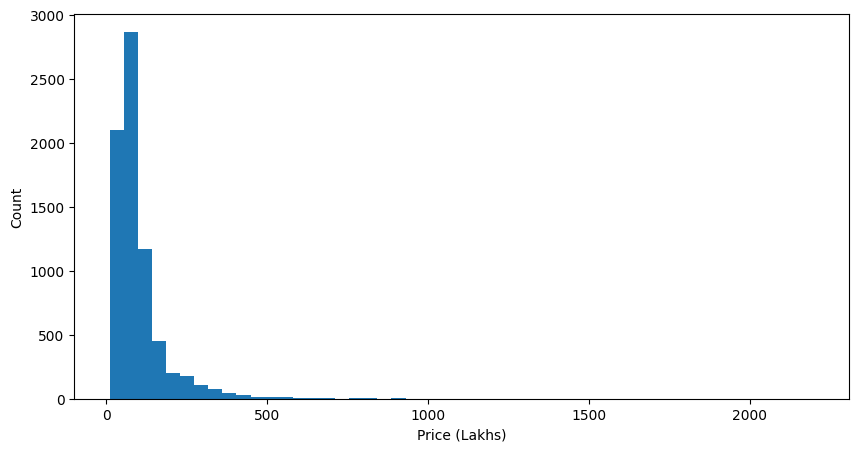

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["price"], bins=50)
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")
plt.show()

In [4]:
df["price"].min(), df["price"].max()

(10.0, 2200.0)

In [5]:
bins = range(0, 2301, 100)

df["price_class"] = pd.cut(
    df["price"], 
    bins=bins,
    labels=False
)

df["price_class"].value_counts().sort_index()

price_class
0     5151
1     1546
2      361
3      143
4       51
5       23
6        9
7        5
8        3
12       1
17       1
20       1
21       1
Name: count, dtype: int64

In [6]:
bins = [0,50,100,150,200,300,500,1000,2500]

df["price_class"] = pd.cut(
    df["price"],
    bins=bins,
    labels=False
)

df["price_class"].value_counts().sort_index()

price_class
0    1865
1    3286
2    1140
3     406
4     361
5     194
6      40
7       4
Name: count, dtype: int64

In [7]:
bins = [0, 50, 100, 150, 200, 300, 500, 2500]

df["price_class"] = pd.cut(
    df["price"],
    bins=bins,
    labels=False
)

df["price_class"].value_counts().sort_index()

price_class
0    1865
1    3286
2    1140
3     406
4     361
5     194
6      44
Name: count, dtype: int64

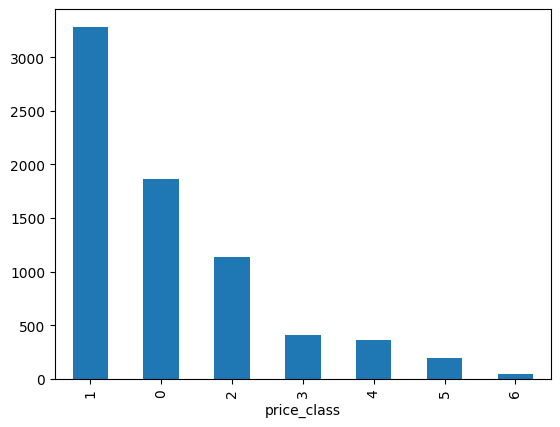

In [8]:
df["price_class"].value_counts().plot(kind="bar")
plt.show()

In [9]:
clf_df = df.drop(
    ["price", "price_per_sqft"],
    axis=1
)

clf_df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,bhk,sqft_per_bhk,price_class
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,1875.0,3.0,1.0,3,625.000000,3
1,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,1500.0,5.0,2.0,5,300.000000,1
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2065.0,4.0,1.0,3,688.333333,4
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2059.0,3.0,2.0,3,686.333333,4
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,1394.0,2.0,1.0,2,697.000000,1


In [10]:
from pycaret.classification import *

s = setup(
    data=clf_df,
    target="price_class",
    session_id=42,
    fold=5,
    html=False,
    verbose=False
)

best_cls = compare_models()

                                    Model  Accuracy     AUC  Recall   Prec.  \
lightgbm  Light Gradient Boosting Machine    0.7486  0.9354  0.7486  0.7450   
gbc          Gradient Boosting Classifier    0.7464  0.0000  0.7464  0.7409   
rf               Random Forest Classifier    0.7384  0.9256  0.7384  0.7356   
et                 Extra Trees Classifier    0.7227  0.9085  0.7227  0.7176   
dt               Decision Tree Classifier    0.7145  0.8047  0.7145  0.7157   
lr                    Logistic Regression    0.6663  0.0000  0.6663  0.6474   
knn                K Neighbors Classifier    0.6636  0.8524  0.6636  0.6568   
lda          Linear Discriminant Analysis    0.6262  0.0000  0.6262  0.6318   
ada                  Ada Boost Classifier    0.5539  0.0000  0.5539  0.4726   
ridge                    Ridge Classifier    0.5502  0.0000  0.5502  0.5464   
nb                            Naive Bayes    0.4506  0.8145  0.4506  0.4488   
dummy                    Dummy Classifier    0.4504 

In [11]:
clf_df

,area_type,availability,location,size,total_sqft,bath,balcony,bhk,sqft_per_bhk,price_class
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,1875.0,3.0,1.0,3,625.000000,3
1,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,1500.0,5.0,2.0,5,300.000000,1
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2065.0,4.0,1.0,3,688.333333,4
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2059.0,3.0,2.0,3,686.333333,4
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,1394.0,2.0,1.0,2,697.000000,1
...,...,...,...,...,...,...,...,...,...,...
7291,Carpet Area,19-Jan,other,2 BHK,1200.0,2.0,3.0,2,600.000000,1
7292,Super built-up Area,Ready To Move,other,1 BHK,1800.0,1.0,1.0,1,1800.000000,3
7293,Super built-up Area,Ready To Move,other,2 BHK,1353.0,2.0,2.0,2,676.500000,2
7294,Plot Area,18-Jan,other,1 Bedroom,812.0,1.0,0.0,1,812.000000,0
